# E-commerce Lifecycle Analytics
## Notebook 1: Data Cleaning and Exploratory Data Analysis

This notebook prepares a sample of e-commerce behavioral event data for lifecycle analysis.

### Objectives
- Load and inspect the raw dataset
- Clean data types and missing values
- Create time-based and business-friendly features
- Explore event, user, session, brand, and category patterns
- Save cleaned data for downstream analysis:
  - Funnel analysis
  - Retention and cohort analysis
  - Customer segmentation

### Dataset columns
- `event_time`: timestamp of event in UTC
- `event_type`: user action (`view`, `cart`, `remove_from_cart`, `purchase`)
- `product_id`: product identifier
- `category_id`: category identifier
- `category_code`: product category taxonomy
- `brand`: product brand
- `price`: product price
- `user_id`: permanent user identifier
- `user_session`: session identifier

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

In [4]:
import pandas as pd
df = pd.read_csv("Data /2019-Oct.csv").sample(2000000, random_state=42)

## 1. Initial inspection

We first inspect:
- shape of the dataset
- column names
- sample records
- data types
- missing values

This helps identify cleaning requirements before analysis.

In [7]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (2000000, 9)

Columns:
['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']


In [8]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
10257365,2019-10-09 02:46:19 UTC,view,29900078,2059484601444729123,NaN,peda,"1,647.40",532353313,47059489-3a63-4353-9eab-0e239d5cb5aa
28875143,2019-10-21 16:17:11 UTC,view,1801805,2053013554415534427,electronics.video.tv,artel,231.60,536042235,a65ee34b-7701-4b25-95e7-45a1259e747e
28709595,2019-10-21 14:42:20 UTC,cart,1004870,2053013555631882655,electronics.smartphone,samsung,284.02,517143806,a9ba13a7-afac-41ca-a3bc-016c580908c3
3458568,2019-10-03 18:40:22 UTC,view,5701087,2053013553970938175,auto.accessories.player,jvc,51.48,556492770,799d5c0a-e1f3-4f22-b61d-ab78cfed068c
25352815,2019-10-19 08:58:51 UTC,view,5300097,2053013563173241677,NaN,remington,39.87,561838859,dd474f7f-0559-41f5-8be0-9d0912cf2b1b


In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 2000000 entries, 10257365 to 38523931
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   event_type     str    
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  str    
 5   brand          str    
 6   price          float64
 7   user_id        int64  
 8   user_session   str    
dtypes: float64(1), int64(3), str(5)
memory usage: 152.6 MB


In [14]:
# missing values check
missing_summary = (
    df.isna()
      .sum()
      .reset_index()
)
missing_summary.columns = ["column", "missing_count"]
missing_summary["missing_pct"] = (
    missing_summary["missing_count"] / len(df) * 100
).round(2)

missing_summary.sort_values("missing_pct", ascending=False)

,column,missing_count,missing_pct
4,category_code,635866,31.80
5,brand,288251,14.41
0,event_time,0,0.00
1,event_type,0,0.00
2,product_id,0,0.00
3,category_id,0,0.00
6,price,0,0.00
7,user_id,0,0.00
8,user_session,0,0.00


In [12]:
# Duplicate check
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 160


In [13]:
df = df.drop_duplicates().copy()
print("Shape after dropping duplicates:", df.shape)

Shape after dropping duplicates: (1999840, 9)


## 2. Data cleaning

In this section, we:
- standardize column types
- parse timestamps
- clean text fields
- handle missing brands and categories
- check invalid prices
- create clean analytical fields

In [15]:
# Standardize column names
df.columns = [col.strip().lower() for col in df.columns]
df.columns

Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='str')

In [17]:
# Convert data types
df["event_time"] = pd.to_datetime(df["event_time"], utc=True, errors="coerce")
print("Null event_time after parsing:", df["event_time"].isna().sum())

Null event_time after parsing: 0


In [68]:
# ------------------------------------------------------------
# Standardizing column data types
# ------------------------------------------------------------
# Identifier columns represent unique keys rather than numeric
# values. Converting them to string prevents accidental math
# operations and keeps them consistent for joins and grouping.

id_cols = ["product_id", "category_id", "user_id", "user_session"]

for col in id_cols:
    df[col] = df[col].astype(str)


# ------------------------------------------------------------
# Converting categorical variables
# ------------------------------------------------------------
# These columns describe the type of event or product attributes.
# Using pandas "string" dtype ensures cleaner text operations
# and consistent categorical handling.

cat_cols = ["event_type", "category_code", "brand"]

for col in cat_cols:
    df[col] = df[col].astype("string")


# ------------------------------------------------------------
# Ensuring numeric price values
# ------------------------------------------------------------
# The price column should be numeric for later analysis such as
# revenue calculation, price segmentation, and basket analysis.
# Any invalid values are coerced into NaN.

df["price"] = pd.to_numeric(df["price"], errors="coerce")


# ------------------------------------------------------------
# Standardizing text fields
# ------------------------------------------------------------
# Clean textual columns by removing extra whitespace and
# converting text to lowercase. This avoids duplicated
# categories caused by inconsistent formatting.

text_cols = ["event_type", "category_code", "brand"]

for col in text_cols:
    df[col] = df[col].str.strip().str.lower()


# ------------------------------------------------------------
# Handling missing categorical values
# ------------------------------------------------------------
# Instead of dropping rows with missing brand or category
# information, we assign placeholder labels. This allows us
# to keep these records in later aggregations and understand
# the scale of unknown products in the dataset.

df["brand"] = df["brand"].fillna("unknown_brand")
df["category_code"] = df["category_code"].fillna("unknown_category")

In [23]:
df[["event_type", "category_code", "brand"]].isna().sum()

event_type       0
category_code    0
brand            0
dtype: int64

In [24]:
df["event_type"].value_counts(dropna=False)

event_type
view        1921140
cart          43511
purchase      35189
Name: count, dtype: Int64

In [25]:
df["price"].describe()

count   1,999,840.00
mean          290.43
std           358.39
min             0.00
25%            66.41
50%           163.20
75%           358.57
max         2,574.07
Name: price, dtype: float64

In [34]:
print("Missing price:", df["price"].isna().sum())
print("Zero price:", (df["price"] == 0).sum())
print("Negative price:", (df["price"] < 0).sum())

df = df[df["price"].notna()].copy()
df = df[df["price"] >= 0].copy()

Missing price: 0
Zero price: 3261
Negative price: 0


In [29]:
# Creates time features

df["event_date"] = df["event_time"].dt.date
df["event_day"] = df["event_time"].dt.day
df["event_month"] = df["event_time"].dt.month
df["event_year"] = df["event_time"].dt.year
df["event_hour"] = df["event_time"].dt.hour
df["day_of_week"] = df["event_time"].dt.day_name()
df["year_month"] = df["event_time"].dt.to_period("M").astype(str)
df["year_week"] = df["event_time"].dt.strftime("%Y-%U")
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

In [30]:
# creates price band
price_bins = [0, 50, 100, 250, 500, 1000, np.inf]
price_labels = ["0-50", "50-100", "100-250", "250-500", "500-1000", "1000+"]

df["price_band"] = pd.cut(
    df["price"],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True
)

In [31]:
df["price_band"].value_counts(dropna=False).sort_index()

price_band
0-50        374552
50-100      317216
100-250     596922
250-500     379689
500-1000    216349
1000+       115112
Name: count, dtype: int64

In [69]:
# ------------------------------------------------------------
# Extracting hierarchical product categories
# ------------------------------------------------------------
# The category_code column contains hierarchical category paths
# separated by dots (e.g., "electronics.smartphone").
# Splitting this allows us to create higher-level product groupings
# that are useful for aggregation and analysis.

# Extract the main (top-level) category
df["main_category"] = df["category_code"].str.split(".").str[0]

# Extract the second-level category for more granular analysis
df["sub_category"] = df["category_code"].str.split(".").str[1]


# ------------------------------------------------------------
# Quick validation of the extracted categories
# ------------------------------------------------------------
# Display a sample of the original category alongside the
# extracted fields to confirm the split worked correctly.

df[["category_code", "main_category", "sub_category"]].head(10)


# ------------------------------------------------------------
# Handling missing category levels
# ------------------------------------------------------------
# Some products may not have a fully specified category path.
# We replace missing values with "unknown" so they remain
# included in category-level aggregations and analyses.

df["main_category"] = df["main_category"].fillna("unknown")
df["sub_category"] = df["sub_category"].fillna("unknown")

In [37]:
df.info()

<class 'pandas.DataFrame'>
Index: 1999840 entries, 10257365 to 38523931
Data columns (total 21 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[us, UTC]
 1   event_type     string             
 2   product_id     str                
 3   category_id    str                
 4   category_code  string             
 5   brand          string             
 6   price          float64            
 7   user_id        str                
 8   user_session   str                
 9   event_date     object             
 10  event_day      int32              
 11  event_month    int32              
 12  event_year     int32              
 13  event_hour     int32              
 14  day_of_week    str                
 15  year_month     str                
 16  year_week      str                
 17  is_weekend     int64              
 18  price_band     category           
 19  main_category  object             
 20  sub_catego

In [38]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,event_date,event_day,event_month,event_year,event_hour,day_of_week,year_month,year_week,is_weekend,price_band,main_category,sub_category
10257365,2019-10-09 02:46:19+00:00,view,29900078,2059484601444729123,unknown_category,peda,"1,647.40",532353313,47059489-3a63-4353-9eab-0e239d5cb5aa,2019-10-09,9,10,2019,2,Wednesday,2019-10,2019-40,0,1000+,unknown_category,unknown
28875143,2019-10-21 16:17:11+00:00,view,1801805,2053013554415534427,electronics.video.tv,artel,231.60,536042235,a65ee34b-7701-4b25-95e7-45a1259e747e,2019-10-21,21,10,2019,16,Monday,2019-10,2019-42,0,100-250,electronics,video
28709595,2019-10-21 14:42:20+00:00,cart,1004870,2053013555631882655,electronics.smartphone,samsung,284.02,517143806,a9ba13a7-afac-41ca-a3bc-016c580908c3,2019-10-21,21,10,2019,14,Monday,2019-10,2019-42,0,250-500,electronics,smartphone
3458568,2019-10-03 18:40:22+00:00,view,5701087,2053013553970938175,auto.accessories.player,jvc,51.48,556492770,799d5c0a-e1f3-4f22-b61d-ab78cfed068c,2019-10-03,3,10,2019,18,Thursday,2019-10,2019-39,0,50-100,auto,accessories
25352815,2019-10-19 08:58:51+00:00,view,5300097,2053013563173241677,unknown_category,remington,39.87,561838859,dd474f7f-0559-41f5-8be0-9d0912cf2b1b,2019-10-19,19,10,2019,8,Saturday,2019-10,2019-41,1,0-50,unknown_category,unknown


In [39]:
df.to_csv("Data /ecommerce_cleaned.csv", index=False)

## 3. Exploratory data analysis

Now that the data is cleaned, we explore:
- event mix
- user and session counts
- category and brand distribution
- price distribution
- temporal activity trends

This gives an initial view of customer behavior before building funnel metrics.

In [40]:
# Dataset overview KPIs
n_rows = len(df)
n_users = df["user_id"].nunique()
n_sessions = df["user_session"].nunique()
n_products = df["product_id"].nunique()
n_categories = df["category_code"].nunique()
n_brands = df["brand"].nunique()

overview = pd.DataFrame({
    "metric": [
        "rows",
        "unique_users",
        "unique_sessions",
        "unique_products",
        "unique_categories",
        "unique_brands"
    ],
    "value": [
        n_rows,
        n_users,
        n_sessions,
        n_products,
        n_categories,
        n_brands
    ]
})

overview

,metric,value
0,rows,1999840
1,unique_users,935717
2,unique_sessions,1575088
3,unique_products,104272
4,unique_categories,127
5,unique_brands,2971


In [42]:
# Event type distribution
event_summary = df["event_type"].value_counts().reset_index()
event_summary.columns = ["event_type", "event_count"]

event_summary["event_pct"] = (
    event_summary["event_count"] / event_summary["event_count"].sum() * 100
).round(2)

event_summary

,event_type,event_count,event_pct
0,view,1921140,96.06
1,cart,43511,2.18
2,purchase,35189,1.76


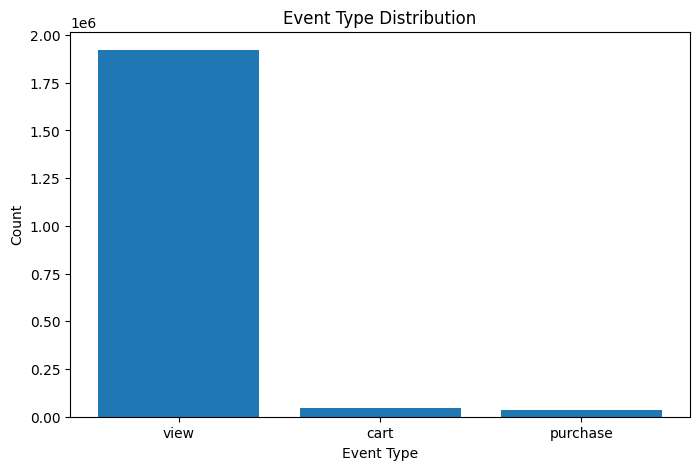

In [43]:
plt.figure(figsize=(8, 5))
plt.bar(event_summary["event_type"], event_summary["event_count"])
plt.title("Event Type Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [45]:
# Daily event trend
daily_events = (
    df.groupby("event_date")
      .size()
      .reset_index(name="event_count")
)

daily_events.head()

,event_date,event_count
0,2019-10-01,58937
1,2019-10-02,55624
2,2019-10-03,53253
3,2019-10-04,66710
4,2019-10-05,62761


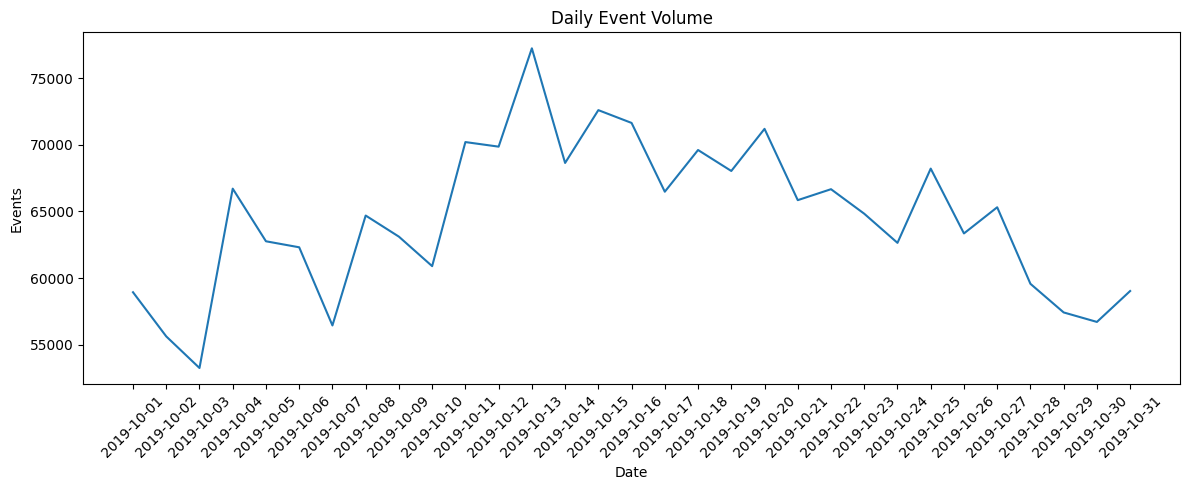

In [46]:
plt.figure(figsize=(12, 5))
plt.plot(daily_events["event_date"].astype(str), daily_events["event_count"])
plt.title("Daily Event Volume")
plt.xlabel("Date")
plt.ylabel("Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [47]:
# Events by day of week
dow_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

dow_summary = (
    df["day_of_week"]
    .value_counts()
    .reindex(dow_order)
    .reset_index()
)
dow_summary.columns = ["day_of_week", "event_count"]
dow_summary

,day_of_week,event_count
0,Monday,250501
1,Tuesday,320321
2,Wednesday,311912
3,Thursday,302301
4,Friday,274738
5,Saturday,264008
6,Sunday,276059


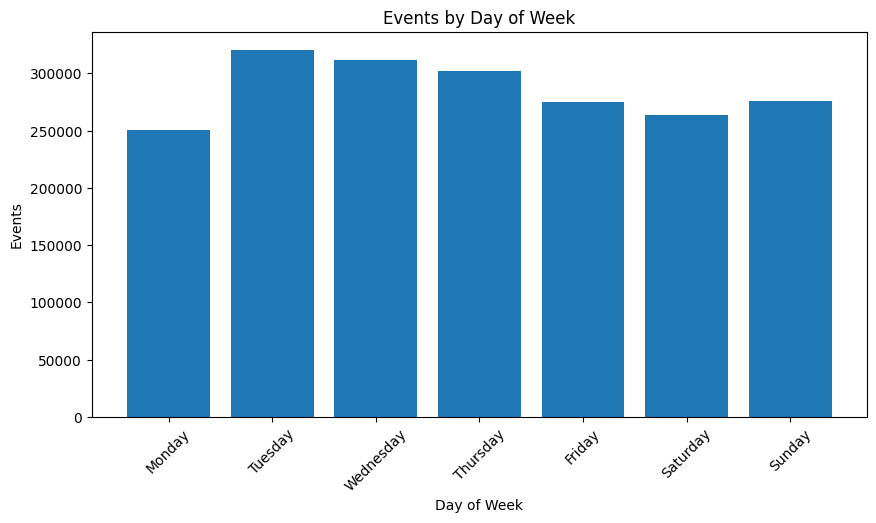

In [48]:
plt.figure(figsize=(10, 5))
plt.bar(dow_summary["day_of_week"], dow_summary["event_count"])
plt.title("Events by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Events")
plt.xticks(rotation=45)
plt.show()

In [49]:
# Hourly Pattern 
hourly_summary = (
    df.groupby("event_hour")
      .size()
      .reset_index(name="event_count")
)

hourly_summary

,event_hour,event_count
0,0,14270
1,1,26053
2,2,50446
3,3,72680
4,4,90449
5,5,99729
6,6,107693
7,7,110062
8,8,112854
9,9,110670


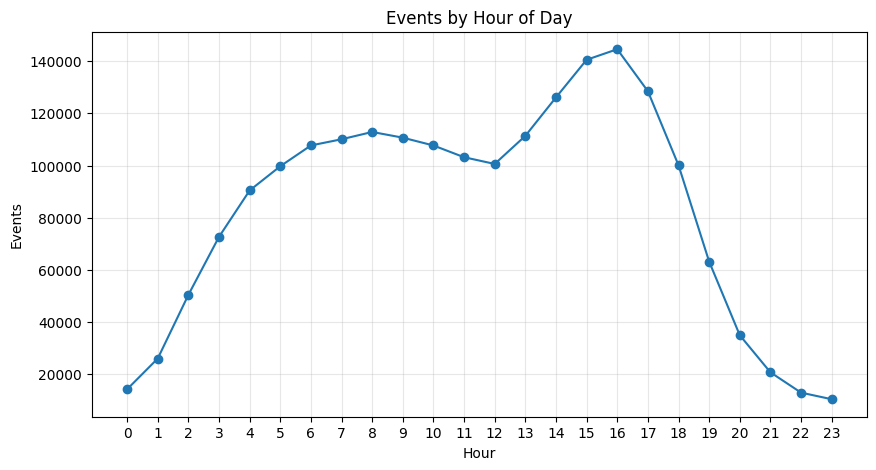

In [50]:
plt.figure(figsize=(10, 5))
plt.plot(hourly_summary["event_hour"], hourly_summary["event_count"], marker="o")
plt.title("Events by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Events")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

In [51]:
# Top categories
top_categories = (
    df["category_code"]
    .value_counts()
    .head(15)
    .reset_index()
)
top_categories.columns = ["category_code", "event_count"]
top_categories

,category_code,event_count
0,unknown_category,635866
1,electronics.smartphone,542032
2,electronics.clocks,61953
3,computers.notebook,53622
4,electronics.video.tv,52525
5,electronics.audio.headphone,51858
6,appliances.kitchen.refrigerators,42024
7,appliances.kitchen.washer,41177
8,appliances.environment.vacuum,37744
9,apparel.shoes,36024


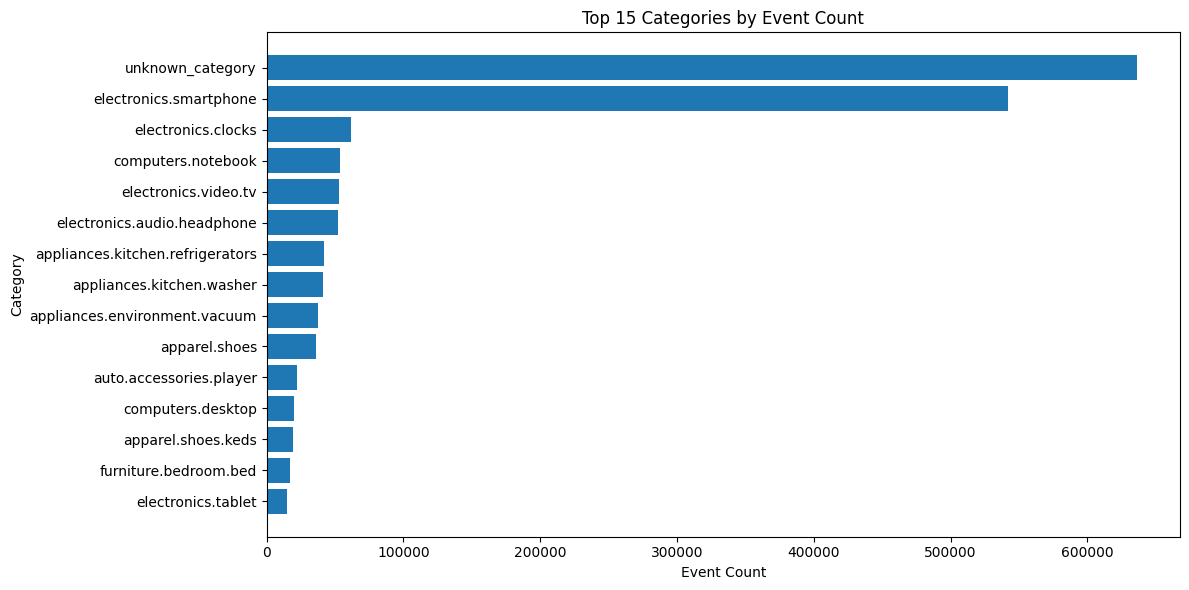

In [52]:
plt.figure(figsize=(12, 6))
plt.barh(top_categories["category_code"][::-1], top_categories["event_count"][::-1])
plt.title("Top 15 Categories by Event Count")
plt.xlabel("Event Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [55]:
# Top main categories
main_category_summary = (
    df["main_category"]
    .value_counts()
    .head(10)
    .reset_index()
)
main_category_summary.columns = ["main_category", "event_count"]
main_category_summary

,main_category,event_count
0,electronics,760539
1,unknown_category,635866
2,appliances,234464
3,computers,109629
4,apparel,72827
5,furniture,58354
6,auto,47808
7,construction,34480
8,kids,24491
9,accessories,11251


In [56]:
# Top Brands
top_brands = (
    df["brand"]
    .value_counts()
    .head(15)
    .reset_index()
)
top_brands.columns = ["brand", "event_count"]
top_brands

,brand,event_count
0,unknown_brand,288251
1,samsung,249372
2,apple,193827
3,xiaomi,145246
4,huawei,52604
5,lucente,30809
6,lg,26783
7,bosch,26262
8,oppo,22769
9,sony,21442


In [57]:
# Price Distribution
df["price"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count   1,999,840.00
mean          290.43
std           358.39
min             0.00
25%            66.41
50%           163.20
75%           358.57
90%           742.59
95%         1,010.14
99%         1,741.34
max         2,574.07
Name: price, dtype: float64

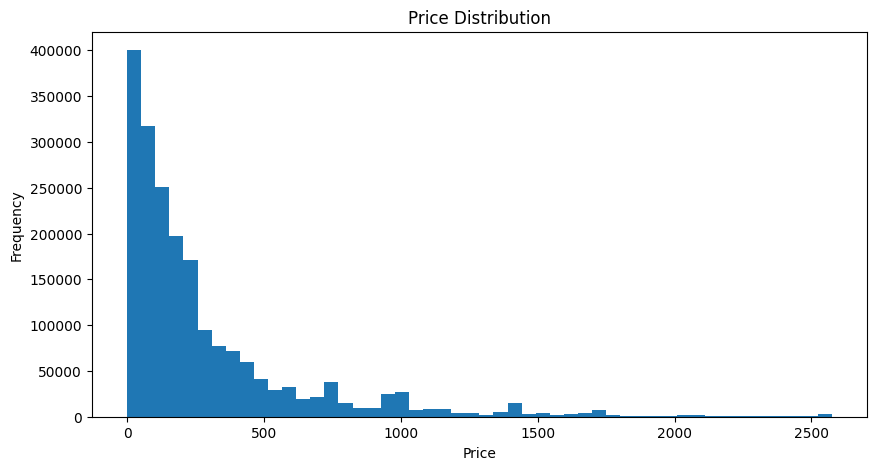

In [58]:
plt.figure(figsize=(10, 5))
plt.hist(df["price"], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [60]:
# Price Band Analysis
price_band_summary = (
    df["price_band"]
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
)
price_band_summary.columns = ["price_band", "event_count"]

price_band_summary["event_pct"] = (
    price_band_summary["event_count"] / price_band_summary["event_count"].sum() * 100
).round(2)

price_band_summary

,price_band,event_count,event_pct
0,0-50,374552,18.73
1,50-100,317216,15.86
2,100-250,596922,29.85
3,250-500,379689,18.99
4,500-1000,216349,10.82
5,1000+,115112,5.76


In [63]:
# User activity summary
user_summary = (
    df.groupby("user_id")
      .agg(
          total_events=("event_type", "count"),
          total_sessions=("user_session", "nunique"),
          total_products_viewed=("product_id", "nunique"),
          total_purchases=("event_type", lambda x: (x == "purchase").sum()),
          total_carts=("event_type", lambda x: (x == "cart").sum()),
          total_revenue=("price", lambda x: x[df.loc[x.index, "event_type"] == "purchase"].sum())
      )
      .reset_index()
)

user_summary.head(10)

,user_id,total_events,total_sessions,total_products_viewed,total_purchases,total_carts,total_revenue
0,195082191,1,1,1,0,0,0.00
1,219406386,1,1,1,0,0,0.00
2,228761834,1,1,1,0,0,0.00
3,239475080,1,1,1,0,0,0.00
4,239876607,1,1,1,0,0,0.00
5,240236728,1,1,1,0,0,0.00
6,244951053,1,1,1,0,0,0.00
7,245978545,1,1,1,0,0,0.00
8,251869926,1,1,1,0,0,0.00
9,253578028,1,1,1,0,0,0.00


In [64]:
user_summary[[
    "total_events",
    "total_sessions",
    "total_products_viewed",
    "total_purchases",
    "total_carts",
    "total_revenue"
]].describe()

,total_events,total_sessions,total_products_viewed,total_purchases,total_carts,total_revenue
count,"935,717.00","935,717.00","935,717.00","935,717.00","935,717.00","935,717.00"
mean,2.14,1.68,1.99,0.04,0.05,11.55
std,2.56,1.65,2.22,0.22,0.25,106.60
min,1.00,1.00,1.00,0.00,0.00,0.00
25%,1.00,1.00,1.00,0.00,0.00,0.00
50%,1.00,1.00,1.00,0.00,0.00,0.00
75%,2.00,2.00,2.00,0.00,0.00,0.00
max,328.00,328.00,117.00,20.00,18.00,"12,746.47"


In [66]:
session_summary = (
    df.groupby("user_session")
      .agg(
          user_id=("user_id", "first"),
          session_start=("event_time", "min"),
          session_end=("event_time", "max"),
          total_events=("event_type", "count"),
          total_views=("event_type", lambda x: (x == "view").sum()),
          total_carts=("event_type", lambda x: (x == "cart").sum()),
          total_removals=("event_type", lambda x: (x == "remove_from_cart").sum()),
          total_purchases=("event_type", lambda x: (x == "purchase").sum()),
          revenue=("price", lambda x: x[df.loc[x.index, "event_type"] == "purchase"].sum())
      )
      .reset_index()
)

session_summary["session_duration_mins"] = (
    (session_summary["session_end"] - session_summary["session_start"])
    .dt.total_seconds() / 60
).round(2)

session_summary["has_cart"] = (session_summary["total_carts"] > 0).astype(int)
session_summary["has_purchase"] = (session_summary["total_purchases"] > 0).astype(int)

session_summary.head(10)

,user_session,user_id,session_start,session_end,total_events,total_views,total_carts,total_removals,total_purchases,revenue,session_duration_mins,has_cart,has_purchase
0,00000056-a206-40dd-b174-a072550fa38c,513782162,2019-10-31 06:23:52+00:00,2019-10-31 06:23:52+00:00,1,1,0,0,0,0.00,0.00,0,0
1,000001fd-1f89-45e8-a3ce-fe3218cabfad,560486342,2019-10-25 08:30:42+00:00,2019-10-25 08:35:30+00:00,2,2,0,0,0,0.00,4.80,0,0
2,000003eb-b63e-45d9-9f26-f229057c654a,512483064,2019-10-03 11:28:52+00:00,2019-10-03 11:28:52+00:00,1,1,0,0,0,0.00,0.00,0,0
3,000011ef-e9fc-4920-96cd-2534bda3cdc2,556327911,2019-10-03 13:18:43+00:00,2019-10-03 13:18:43+00:00,1,1,0,0,0,0.00,0.00,0,0
4,000024a4-d991-4020-a163-f6fdcc80efac,542931037,2019-10-07 19:47:08+00:00,2019-10-07 19:47:08+00:00,1,1,0,0,0,0.00,0.00,0,0
5,000024c3-e526-45d6-849a-4816599dcb6d,546857180,2019-10-07 11:46:48+00:00,2019-10-07 11:46:48+00:00,1,1,0,0,0,0.00,0.00,0,0
6,000036df-a712-4097-b47f-f2070d2ae5d9,515877056,2019-10-26 06:07:56+00:00,2019-10-26 06:07:56+00:00,1,1,0,0,0,0.00,0.00,0,0
7,00005163-681d-4227-b7cb-99138b3298e7,560388561,2019-10-15 07:56:45+00:00,2019-10-15 07:56:45+00:00,1,1,0,0,0,0.00,0.00,0,0
8,00005ffb-a645-45e0-8b27-68256b3e6364,549824345,2019-10-21 11:06:23+00:00,2019-10-21 11:06:23+00:00,1,1,0,0,0,0.00,0.00,0,0
9,00009747-136e-4af9-a182-0d9a1155e3cd,538156455,2019-10-08 12:23:57+00:00,2019-10-08 12:23:57+00:00,1,1,0,0,0,0.00,0.00,0,0


In [67]:
user_summary.to_csv("Data /user_summary.csv", index=False)
session_summary.to_csv("Data /session_summary.csv", index=False)

## 4. Key Insights

- The cleaned sample contains **1.99M events**, **935.7K users**, and **1.58M sessions**, providing a strong base for lifecycle analysis.
- Missing values are concentrated in `category_code` (**31.8%**) and `brand` (**14.4%**), so these were standardized as `unknown_category` and `unknown_brand` to retain coverage.
- User behavior is highly top-of-funnel:
  - **96.06%** views
  - **2.18%** carts
  - **1.76%** purchases
- This indicates that the main lifecycle drop-off is likely between product discovery and purchase intent.
- The sample is heavily concentrated in **electronics**, especially **smartphones**, with brands such as **Samsung**, **Apple**, and **Xiaomi** dominating event volume.
- Pricing is right-skewed, with a median price of **163.20** and the largest activity share in the **100–250** price band.
- Most users are low-frequency visitors, with median behavior of **1 event**, **1 session**, and **1 viewed product**, suggesting a large base of casual browsers.
- Activity peaks during the **afternoon (15:00–16:00 UTC)** and is strongest midweek, especially on **Tuesday–Thursday**.
- These findings set up the next phase of analysis: **funnel conversion by user, session, category, brand, and price band**.